In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
unemployment = pd.read_csv(
    "../data/raw/UNRATE.csv",
    parse_dates=["date"]
)

unemployment.head()

,date,UNRATE
0,1990-01-01,5.4
1,1990-02-01,5.3
2,1990-03-01,5.2
3,1990-04-01,5.4
4,1990-05-01,5.4


In [3]:
unemployment.info()

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    439 non-null    datetime64[us]
 1   UNRATE  438 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 7.0 KB


In [4]:
unemployment.describe()

,date,UNRATE
count,439,438.000000
mean,2008-03-31 23:40:19.134396,5.654795
min,1990-01-01 00:00:00,3.400000
25%,1999-02-15 00:00:00,4.300000
50%,2008-04-01 00:00:00,5.300000
75%,2017-05-16 12:00:00,6.575000
max,2026-07-01 00:00:00,14.800000
std,NaN,1.736738


In [5]:
unemployment.isna().sum()

date      0
UNRATE    1
dtype: int64

In [6]:
unemployment[unemployment["UNRATE"].isna()]

,date,UNRATE
429,2025-10-01,NaN


In [7]:
unemployment.loc[426:432]

,date,UNRATE
426,2025-07-01,4.3
427,2025-08-01,4.3
428,2025-09-01,4.4
429,2025-10-01,NaN
430,2025-11-01,4.5
431,2025-12-01,4.4
432,2026-01-01,4.3


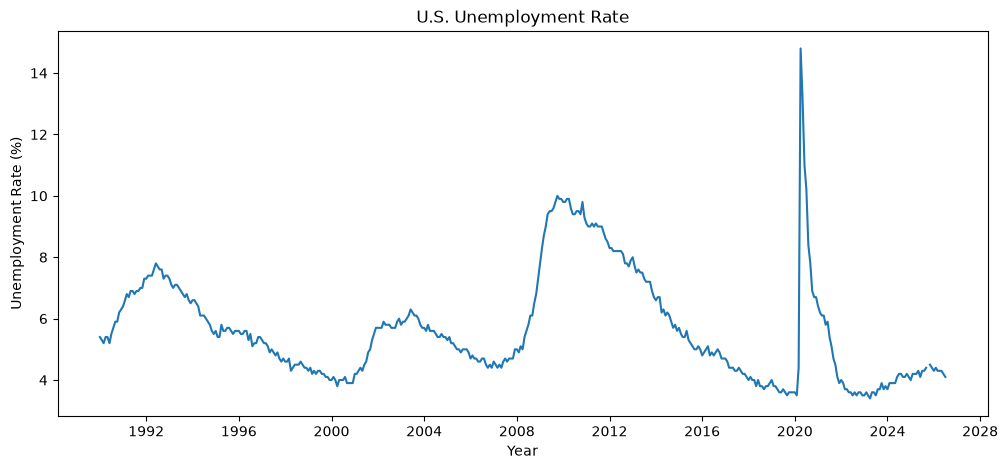

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    unemployment["date"],
    unemployment["UNRATE"]
)

plt.title("U.S. Unemployment Rate")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [9]:
recession = pd.read_csv(
    "../data/raw/USREC.csv",
    parse_dates=["date"]
)

recession.head()

,date,USREC
0,1990-01-01,0
1,1990-02-01,0
2,1990-03-01,0
3,1990-04-01,0
4,1990-05-01,0


In [10]:
recession[recession["USREC"] == 1].head(20)

,date,USREC
7,1990-08-01,1
8,1990-09-01,1
9,1990-10-01,1
10,1990-11-01,1
11,1990-12-01,1
12,1991-01-01,1
13,1991-02-01,1
14,1991-03-01,1
135,2001-04-01,1
136,2001-05-01,1


In [11]:
recession["USREC"].value_counts()

USREC
0    403
1     36
Name: count, dtype: int64

In [12]:
unemployment_recession = pd.merge(
    unemployment,
    recession,
    on="date",
    how="left"
)

unemployment_recession.head()

,date,UNRATE,USREC
0,1990-01-01,5.4,0
1,1990-02-01,5.3,0
2,1990-03-01,5.2,0
3,1990-04-01,5.4,0
4,1990-05-01,5.4,0


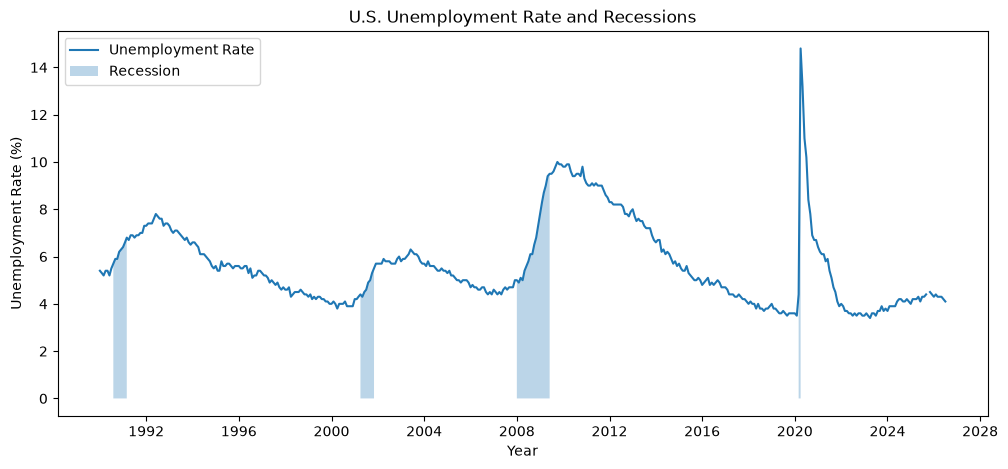

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    unemployment_recession["date"],
    unemployment_recession["UNRATE"],
    label="Unemployment Rate"
)

plt.fill_between(
    unemployment_recession["date"],
    0,
    unemployment_recession["UNRATE"],
    where=unemployment_recession["USREC"] == 1,
    alpha=0.3,
    label="Recession"
)

plt.title("U.S. Unemployment Rate and Recessions")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.legend()

plt.show()